In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import networkx as nx
from networkx.algorithms import smallworld
import random
from collections import Counter
from scipy.spatial import cKDTree

from tqdm import tqdm

import pandas as pd
import seaborn as sns

In [3]:
from src.neuron_population import NeuronPopulation
from src.connectome import Connectome
from src.overhead import Simulation
from src.neuron_templates import neuron_type_IZ
from src.network_grower import *
from src.network_generators import *
from src.neuron_type_distributor import *
from src.network_weight_distributor import *
from src.external_inputs import *

## DF

In [4]:
# df = pd.read_csv("higher_sweep.csv")
# df = pd.read_csv("week12_normalize_target_sweep.csv")
# df = pd.read_csv("week12_normalize_target_bfactor_sweep.csv")
df = pd.read_csv("results/peak_voltage_heterogeneity_grid_search.csv")
# df = pd.read_csv("week12_normalize_target_random_topology_sweep.csv")

In [5]:
df

,job_index,num_jobs,topology,generator_name,topology_seed,variance_ss4_vp,variance_b_vp,truncate_std,heterogeneity_param_index,heterogeneity_param_name,...,mean_noise_corr_500ms,mean_noise_corr_1000ms,participation_frac_mean_300ms,participation_frac_median_300ms,participation_frac_p95_300ms,participation_frac_total,participation_frac_total_E,participation_frac_total_I,psd_peak_ratio,pop_spec_entropy
0,0,4,fixed,generate_random_fixed_indegree_ei_network,1234,0,0,2.0,6,Vp,...,0.009716,0.017293,0.6040,0.6080,0.65240,0.974,0.96750,1.0,140.537001,8.930017
1,1,4,fixed,generate_random_fixed_indegree_ei_network,1234,0,1,2.0,6,Vp,...,0.005295,0.012415,0.5971,0.5945,0.63855,0.986,0.98250,1.0,160.733743,8.863910
2,2,4,fixed,generate_random_fixed_indegree_ei_network,1234,0,2,2.0,6,Vp,...,0.009713,0.018059,0.6118,0.6045,0.66150,0.982,0.97750,1.0,84.182874,8.931069
3,3,4,fixed,generate_random_fixed_indegree_ei_network,1234,0,4,2.0,6,Vp,...,0.014574,0.012904,0.5937,0.5835,0.64650,0.985,0.98125,1.0,64.305917,8.949654
4,0,4,fixed,generate_random_fixed_indegree_ei_network,1234,0,7,2.0,6,Vp,...,0.004386,0.005003,0.6107,0.6050,0.66120,0.986,0.98250,1.0,108.681038,8.958259
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,3,4,spatial,generate_spatial_ei_network,1238,10,1,2.0,6,Vp,...,0.019661,0.010418,0.7034,0.6940,0.77985,0.999,0.99875,1.0,214.896717,8.205312
356,0,4,spatial,generate_spatial_ei_network,1238,10,2,2.0,6,Vp,...,0.023492,0.033112,0.7123,0.7090,0.79840,1.000,1.00000,1.0,110.023586,8.179308
357,1,4,spatial,generate_spatial_ei_network,1238,10,4,2.0,6,Vp,...,0.031645,0.035077,0.6987,0.6875,0.77960,0.999,0.99875,1.0,236.294559,8.211437
358,2,4,spatial,generate_spatial_ei_network,1238,10,7,2.0,6,Vp,...,0.013352,0.005650,0.7070,0.6975,0.77055,1.000,1.00000,1.0,72.331047,8.176860


In [6]:
# df with removed columns generator_name, num_jobs, job_index, topology_seed
df = df.drop(columns=["generator_name", "num_jobs", "job_index", "topology_seed", "heterogeneity_param_name", "normalize_mode_topology", "runtime_plasticity", "runtime_rate_normalization"])

In [7]:
df

,topology,variance_ss4_vp,variance_b_vp,truncate_std,heterogeneity_param_index,n_neurons,fixed_indegree,dt_ms,sim_ms,input_rate_hz,...,mean_noise_corr_500ms,mean_noise_corr_1000ms,participation_frac_mean_300ms,participation_frac_median_300ms,participation_frac_p95_300ms,participation_frac_total,participation_frac_total_E,participation_frac_total_I,psd_peak_ratio,pop_spec_entropy
0,fixed,0,0,2.0,6,1000,100,0.1,3000.0,50.0,...,0.009716,0.017293,0.6040,0.6080,0.65240,0.974,0.96750,1.0,140.537001,8.930017
1,fixed,0,1,2.0,6,1000,100,0.1,3000.0,50.0,...,0.005295,0.012415,0.5971,0.5945,0.63855,0.986,0.98250,1.0,160.733743,8.863910
2,fixed,0,2,2.0,6,1000,100,0.1,3000.0,50.0,...,0.009713,0.018059,0.6118,0.6045,0.66150,0.982,0.97750,1.0,84.182874,8.931069
3,fixed,0,4,2.0,6,1000,100,0.1,3000.0,50.0,...,0.014574,0.012904,0.5937,0.5835,0.64650,0.985,0.98125,1.0,64.305917,8.949654
4,fixed,0,7,2.0,6,1000,100,0.1,3000.0,50.0,...,0.004386,0.005003,0.6107,0.6050,0.66120,0.986,0.98250,1.0,108.681038,8.958259
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,spatial,10,1,2.0,6,1000,100,0.1,3000.0,50.0,...,0.019661,0.010418,0.7034,0.6940,0.77985,0.999,0.99875,1.0,214.896717,8.205312
356,spatial,10,2,2.0,6,1000,100,0.1,3000.0,50.0,...,0.023492,0.033112,0.7123,0.7090,0.79840,1.000,1.00000,1.0,110.023586,8.179308
357,spatial,10,4,2.0,6,1000,100,0.1,3000.0,50.0,...,0.031645,0.035077,0.6987,0.6875,0.77960,0.999,0.99875,1.0,236.294559,8.211437
358,spatial,10,7,2.0,6,1000,100,0.1,3000.0,50.0,...,0.013352,0.005650,0.7070,0.6975,0.77055,1.000,1.00000,1.0,72.331047,8.176860


In [8]:
# Meaned df by same variance_ss4_vp and variance_b_vp
grouped_df = df.groupby(["topology", "variance_ss4_vp", "variance_b_vp"]).mean().reset_index()
grouped_df

,topology,variance_ss4_vp,variance_b_vp,truncate_std,heterogeneity_param_index,n_neurons,fixed_indegree,dt_ms,sim_ms,input_rate_hz,...,mean_noise_corr_500ms,mean_noise_corr_1000ms,participation_frac_mean_300ms,participation_frac_median_300ms,participation_frac_p95_300ms,participation_frac_total,participation_frac_total_E,participation_frac_total_I,psd_peak_ratio,pop_spec_entropy
0,fixed,0,0,2.0,6.0,1000.0,100.0,0.1,3000.0,50.0,...,0.012071,0.010222,0.58702,0.5871,0.64643,0.9780,0.97250,1.000,131.816383,8.933400
1,fixed,0,1,2.0,6.0,1000.0,100.0,0.1,3000.0,50.0,...,0.010555,0.014509,0.59352,0.5851,0.64833,0.9880,0.98500,1.000,117.943060,8.929367
2,fixed,0,2,2.0,6.0,1000.0,100.0,0.1,3000.0,50.0,...,0.012147,0.011624,0.59348,0.5848,0.65212,0.9796,0.97450,1.000,143.525682,8.897485
3,fixed,0,4,2.0,6.0,1000.0,100.0,0.1,3000.0,50.0,...,0.011088,0.008215,0.58842,0.5795,0.65383,0.9854,0.98175,1.000,82.507776,8.895592
4,fixed,0,7,2.0,6.0,1000.0,100.0,0.1,3000.0,50.0,...,0.010709,0.009342,0.59342,0.5890,0.65067,0.9826,0.97825,1.000,120.777458,8.947660
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,spatial,10,1,2.0,6.0,1000.0,100.0,0.1,3000.0,50.0,...,0.040312,0.032631,0.69510,0.6868,0.78600,0.9994,0.99925,1.000,190.600108,7.871501
68,spatial,10,2,2.0,6.0,1000.0,100.0,0.1,3000.0,50.0,...,0.026971,0.030136,0.69324,0.6948,0.78396,0.9994,0.99925,1.000,138.018564,8.000172
69,spatial,10,4,2.0,6.0,1000.0,100.0,0.1,3000.0,50.0,...,0.028027,0.033109,0.68286,0.6776,0.78185,0.9988,0.99875,0.999,148.959868,8.102244
70,spatial,10,7,2.0,6.0,1000.0,100.0,0.1,3000.0,50.0,...,0.022121,0.012797,0.69242,0.6852,0.77597,0.9988,0.99850,1.000,101.507874,8.085012


## Heatmaps

### PSD peak ratio

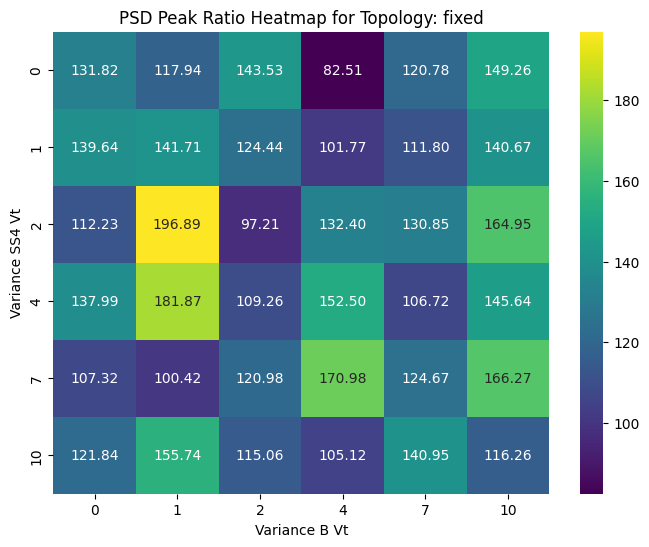

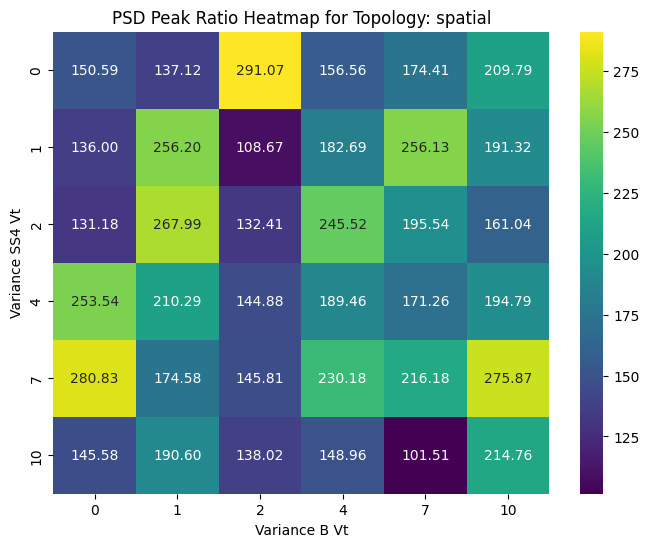

In [9]:
# psd_peak_ratio heatmap for variance_ss4_vp vs variance_b_vp for each topology
for topology in grouped_df["topology"].unique():
    subset = grouped_df[grouped_df["topology"] == topology]
    pivot_table = subset.pivot(index="variance_ss4_vp", columns="variance_b_vp", values="psd_peak_ratio")
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="viridis")
    plt.title(f"PSD Peak Ratio Heatmap for Topology: {topology}")
    plt.xlabel("Variance B Vt")
    plt.ylabel("Variance SS4 Vt")
    plt.show()

### Noise correlation

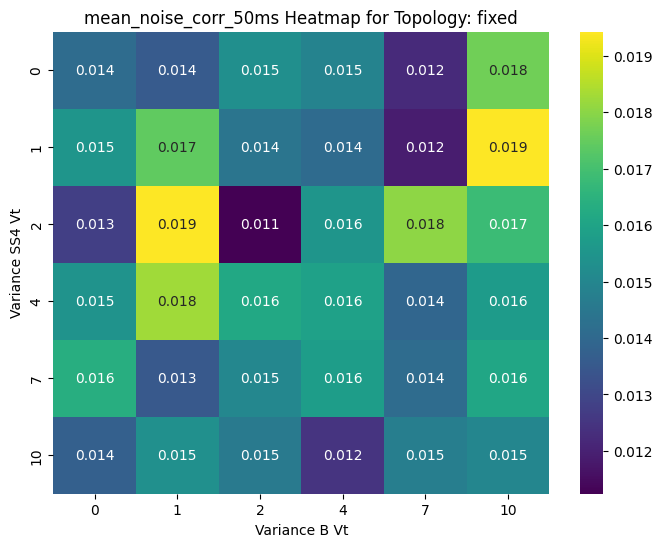

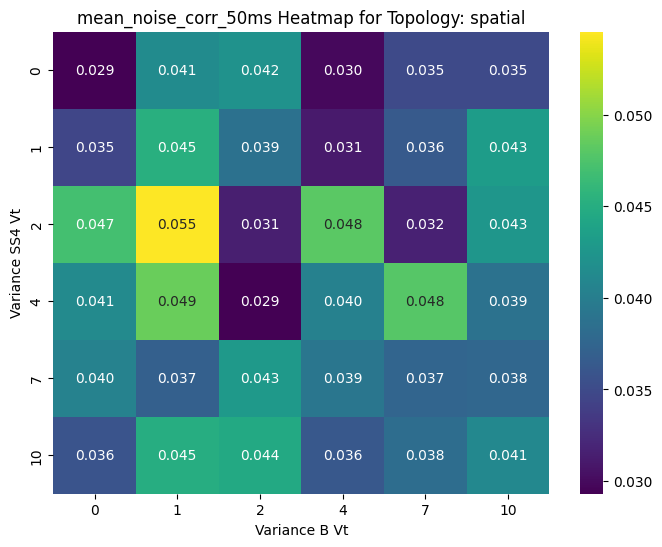

In [10]:
# psd_peak_ratio heatmap for variance_ss4_vp vs variance_b_vp for each topology
for topology in grouped_df["topology"].unique():
    subset = grouped_df[grouped_df["topology"] == topology]
    pivot_table = subset.pivot(index="variance_ss4_vp", columns="variance_b_vp", values="mean_noise_corr_50ms")
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title(f"mean_noise_corr_50ms Heatmap for Topology: {topology}")
    plt.xlabel("Variance B Vt")
    plt.ylabel("Variance SS4 Vt")
    plt.show()

### ISI CV

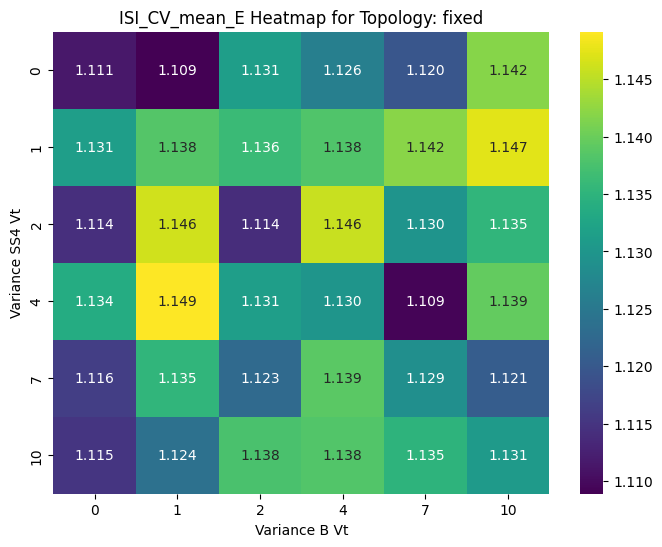

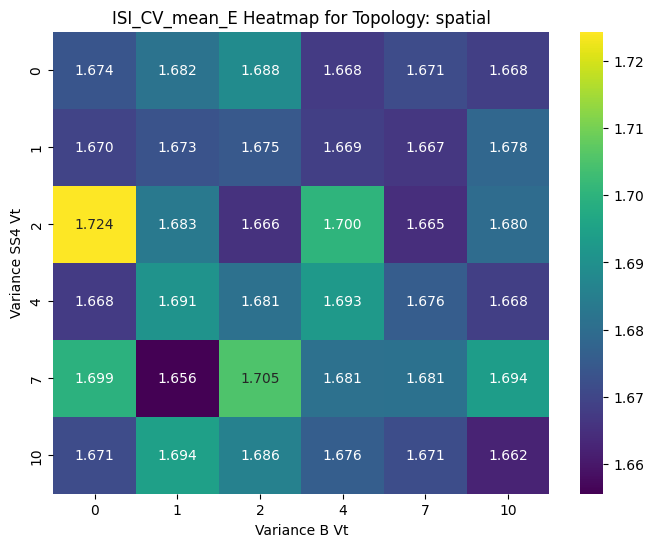

In [11]:
# psd_peak_ratio heatmap for variance_ss4_vp vs variance_b_vp for each topology
for topology in grouped_df["topology"].unique():
    subset = grouped_df[grouped_df["topology"] == topology]
    pivot_table = subset.pivot(index="variance_ss4_vp", columns="variance_b_vp", values="ISI_CV_mean_E")
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title(f"ISI_CV_mean_E Heatmap for Topology: {topology}")
    plt.xlabel("Variance B Vt")
    plt.ylabel("Variance SS4 Vt")
    plt.show()

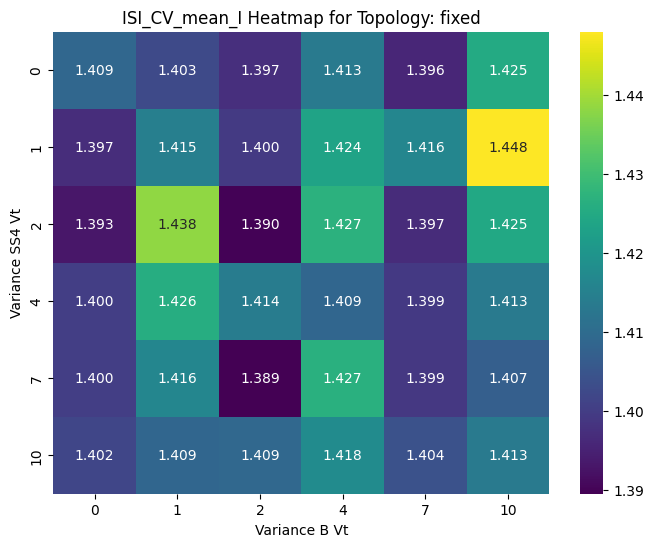

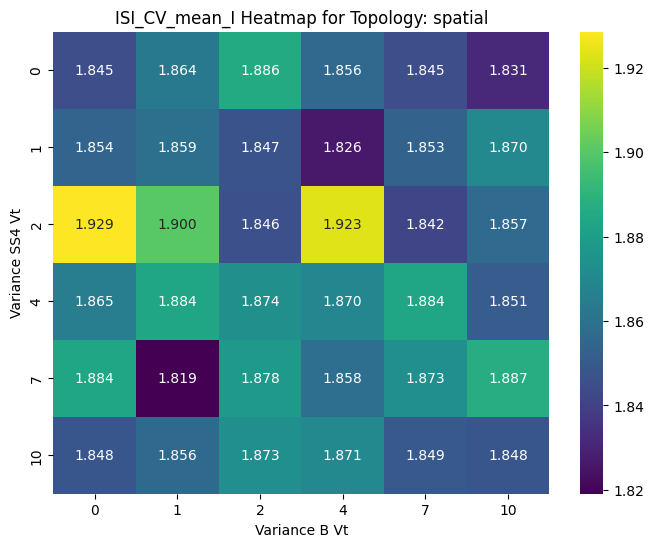

In [12]:
# psd_peak_ratio heatmap for variance_ss4_vp vs variance_b_vp for each topology
for topology in grouped_df["topology"].unique():
    subset = grouped_df[grouped_df["topology"] == topology]
    pivot_table = subset.pivot(index="variance_ss4_vp", columns="variance_b_vp", values="ISI_CV_mean_I")
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title(f"ISI_CV_mean_I Heatmap for Topology: {topology}")
    plt.xlabel("Variance B Vt")
    plt.ylabel("Variance SS4 Vt")
    plt.show()

### Fano

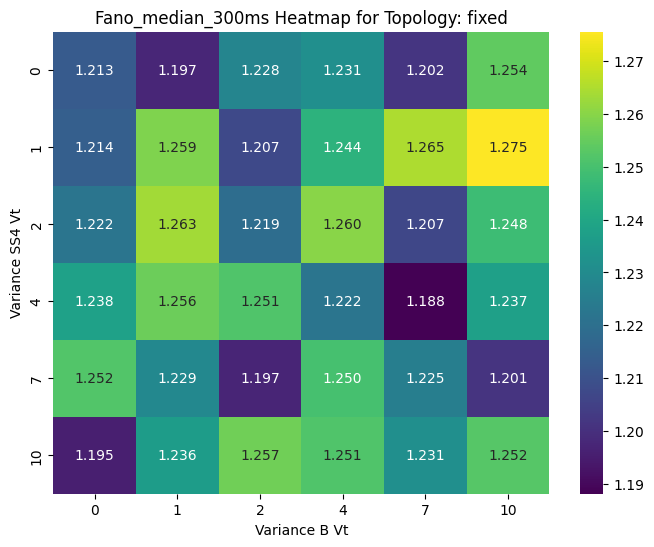

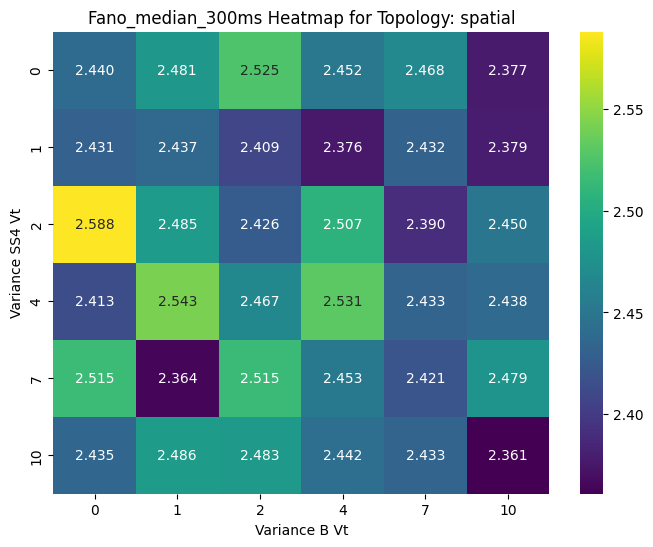

In [13]:
# psd_peak_ratio heatmap for variance_ss4_vp vs variance_b_vp for each topology
for topology in grouped_df["topology"].unique():
    subset = grouped_df[grouped_df["topology"] == topology]
    pivot_table = subset.pivot(index="variance_ss4_vp", columns="variance_b_vp", values="Fano_median_300ms")
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title(f"Fano_median_300ms Heatmap for Topology: {topology}")
    plt.xlabel("Variance B Vt")
    plt.ylabel("Variance SS4 Vt")
    plt.show()

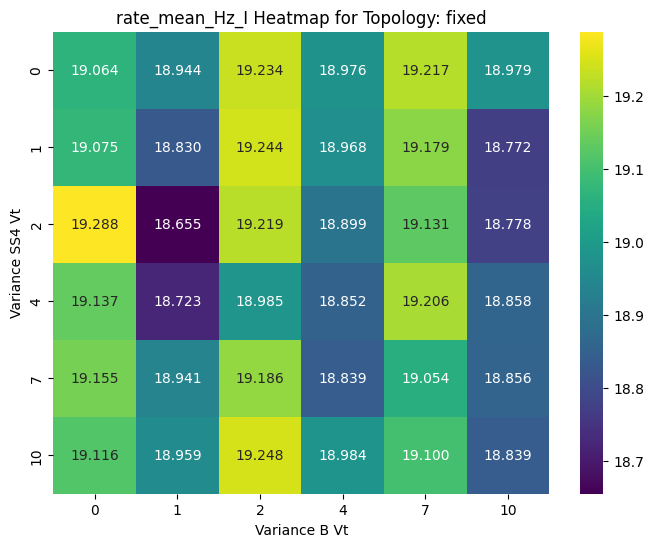

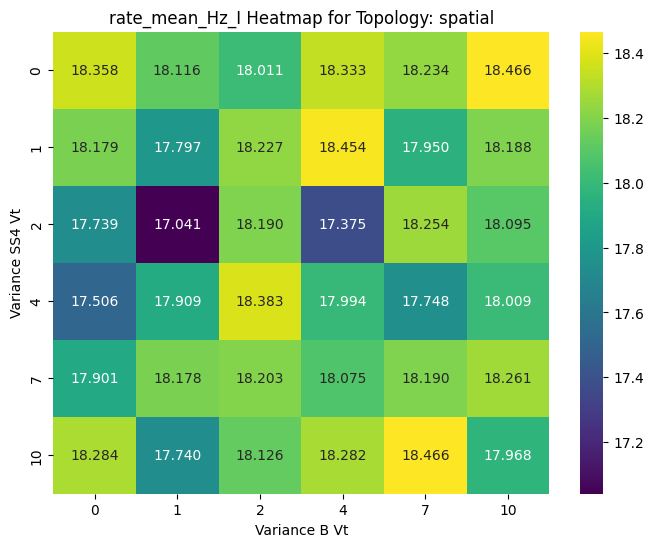

In [15]:
# psd_peak_ratio heatmap for variance_ss4_vt vs variance_b_vt for each topology
for topology in grouped_df["topology"].unique():
    subset = grouped_df[grouped_df["topology"] == topology]
    pivot_table = subset.pivot(index="variance_ss4_vp", columns="variance_b_vp", values="rate_mean_Hz_I")
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title(f"rate_mean_Hz_I Heatmap for Topology: {topology}")
    plt.xlabel("Variance B Vt")
    plt.ylabel("Variance SS4 Vt")
    plt.show()

## Correlations

Correlations for Topology: fixed
Correlation with psd_peak_ratio:
                 variance_ss4_vp  variance_b_vp  psd_peak_ratio
variance_ss4_vp     1.000000e+00   1.600321e-17       -0.009736
variance_b_vp       1.600321e-17   1.000000e+00        0.125938
psd_peak_ratio     -9.736185e-03   1.259383e-01        1.000000

Correlation with mean_noise_corr_50ms:
                      variance_ss4_vp  variance_b_vp  mean_noise_corr_50ms
variance_ss4_vp          1.000000e+00   1.600321e-17             -0.119486
variance_b_vp            1.600321e-17   1.000000e+00              0.168446
mean_noise_corr_50ms    -1.194865e-01   1.684464e-01              1.000000

Correlation with ISI_CV_mean_E:
                 variance_ss4_vp  variance_b_vp  ISI_CV_mean_E
variance_ss4_vp     1.000000e+00   1.600321e-17      -0.041878
variance_b_vp       1.600321e-17   1.000000e+00       0.245408
ISI_CV_mean_E      -4.187815e-02   2.454077e-01       1.000000

Correlation with ISI_CV_mean_I:
                 var

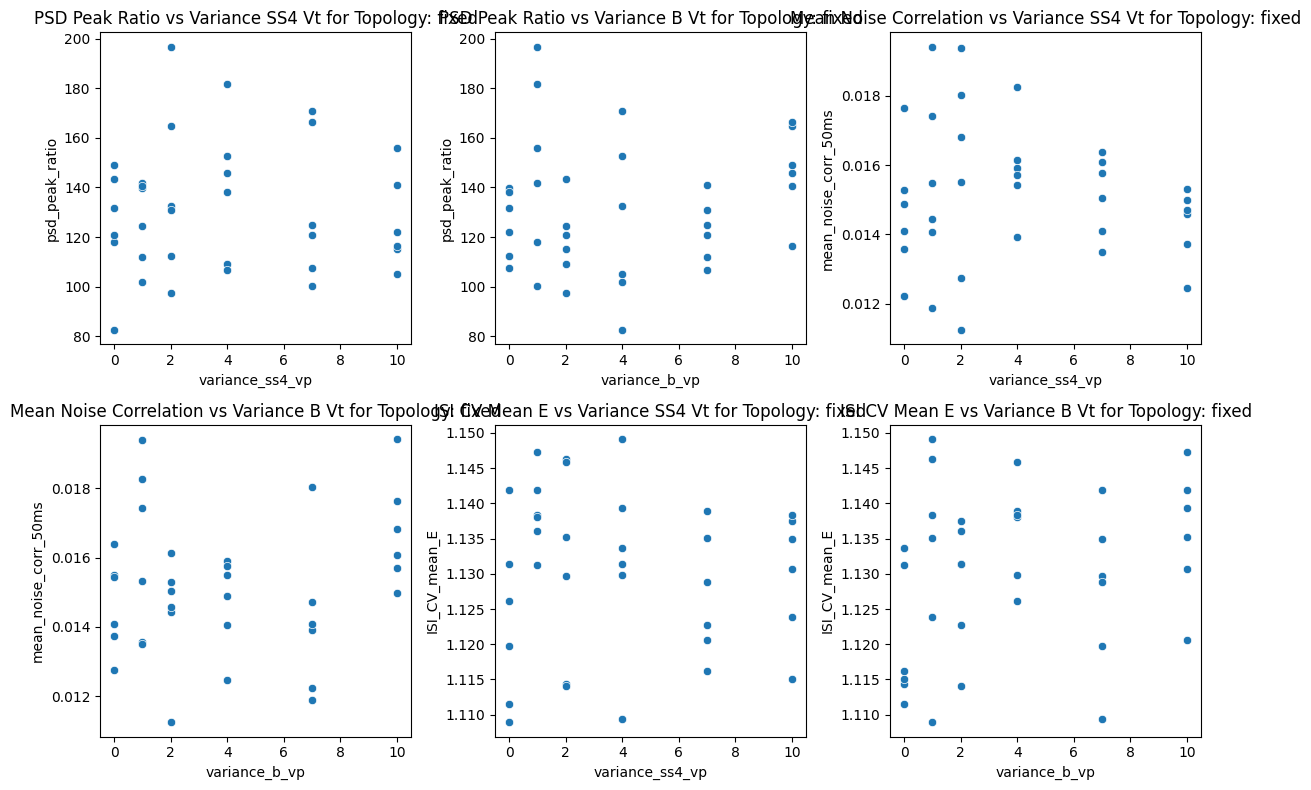

Correlations for Topology: spatial
Correlation with psd_peak_ratio:
                 variance_ss4_vp  variance_b_vp  psd_peak_ratio
variance_ss4_vp     1.000000e+00   1.600321e-17       -0.082646
variance_b_vp       1.600321e-17   1.000000e+00        0.125530
psd_peak_ratio     -8.264595e-02   1.255301e-01        1.000000

Correlation with mean_noise_corr_50ms:
                      variance_ss4_vp  variance_b_vp  mean_noise_corr_50ms
variance_ss4_vp          1.000000e+00   1.600321e-17              0.135175
variance_b_vp            1.600321e-17   1.000000e+00             -0.103970
mean_noise_corr_50ms     1.351751e-01  -1.039701e-01              1.000000

Correlation with ISI_CV_mean_E:
                 variance_ss4_vp  variance_b_vp  ISI_CV_mean_E
variance_ss4_vp     1.000000e+00   1.600321e-17       0.103828
variance_b_vp       1.600321e-17   1.000000e+00      -0.266137
ISI_CV_mean_E       1.038275e-01  -2.661368e-01       1.000000

Correlation with ISI_CV_mean_I:
                 v

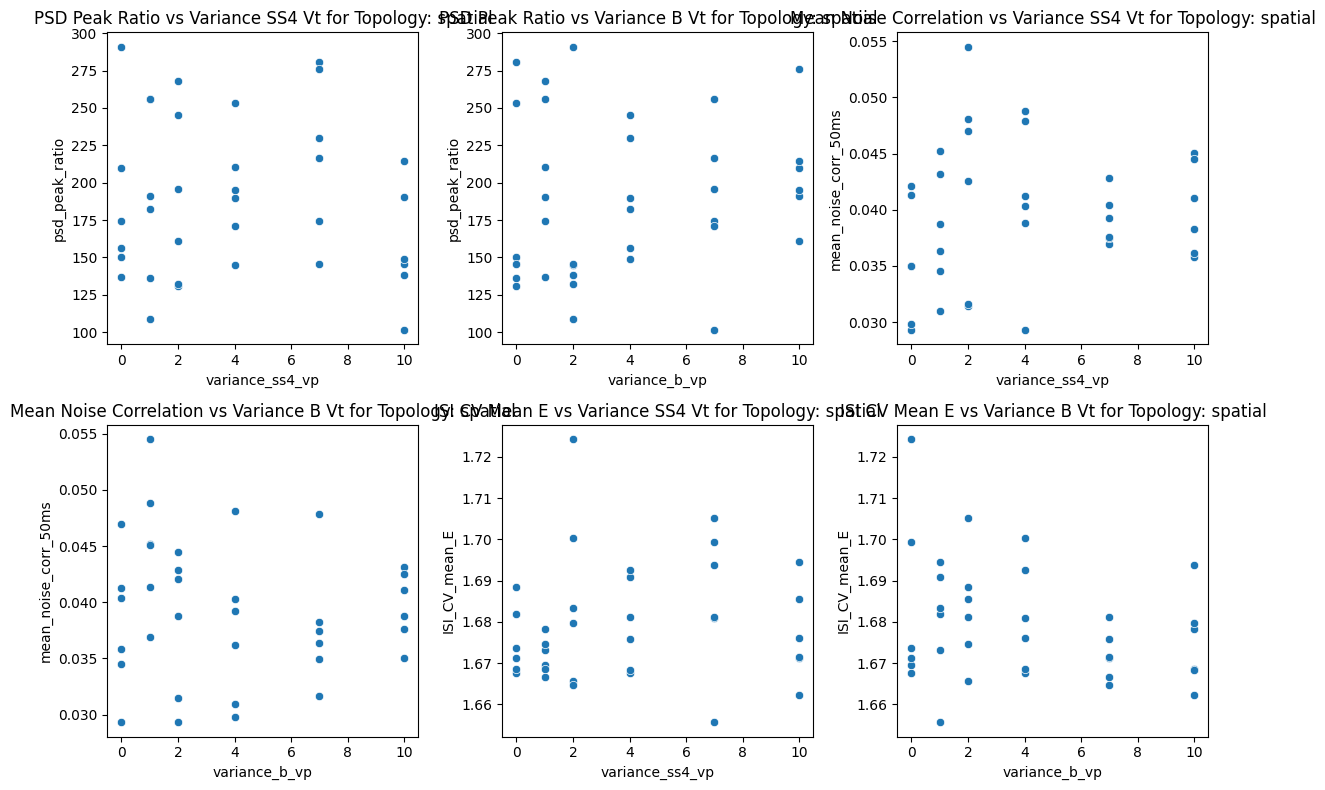

In [16]:
# Correlations for variance_ss4_vp and variance_b_vp for each topology, vs psd_peak_ratio, mean_noise_corr_50ms, ISI_CV_mean_E, ISI_CV_mean_I, Fano_median_300ms
for topology in grouped_df["topology"].unique():
    subset = grouped_df[grouped_df["topology"] == topology]
    corr_psd_peak_ratio = subset[["variance_ss4_vp", "variance_b_vp", "psd_peak_ratio"]].corr()
    corr_mean_noise_corr_50ms = subset[["variance_ss4_vp", "variance_b_vp", "mean_noise_corr_50ms"]].corr()
    corr_ISI_CV_mean_E = subset[["variance_ss4_vp", "variance_b_vp", "ISI_CV_mean_E"]].corr()
    corr_ISI_CV_mean_I = subset[["variance_ss4_vp", "variance_b_vp", "ISI_CV_mean_I"]].corr()
    corr_Fano_median_300ms = subset[["variance_ss4_vp", "variance_b_vp", "Fano_median_300ms"]].corr()
    corr_rate_mean_Hz_E = subset[["variance_ss4_vp", "variance_b_vp", "rate_mean_Hz_E"]].corr()
    corr_rate_mean_Hz_I = subset[["variance_ss4_vp", "variance_b_vp", "rate_mean_Hz_I"]].corr()
    
    print(f"Correlations for Topology: {topology}")
    print("Correlation with psd_peak_ratio:")
    print(corr_psd_peak_ratio)
    print("\nCorrelation with mean_noise_corr_50ms:")
    print(corr_mean_noise_corr_50ms)
    print("\nCorrelation with ISI_CV_mean_E:")
    print(corr_ISI_CV_mean_E)
    print("\nCorrelation with ISI_CV_mean_I:")
    print(corr_ISI_CV_mean_I)
    print("\nCorrelation with Fano_median_300ms:")
    print(corr_Fano_median_300ms)
    print("\nCorrelation with rate_mean_Hz_E:")
    print(corr_rate_mean_Hz_E)
    print("\nCorrelation with rate_mean_Hz_I:")
    print(corr_rate_mean_Hz_I)
    print("\n" + "="*50 + "\n")

    # Plot
    plt.figure(figsize=(12, 8))
    plt.subplot(2, 3, 1)
    sns.scatterplot(data=subset, x="variance_ss4_vp", y="psd_peak_ratio")
    plt.title(f"PSD Peak Ratio vs Variance SS4 Vt for Topology: {topology}")
    plt.subplot(2, 3, 2)
    sns.scatterplot(data=subset, x="variance_b_vp", y="psd_peak_ratio")
    plt.title(f"PSD Peak Ratio vs Variance B Vt for Topology: {topology}")
    plt.subplot(2, 3, 3)
    sns.scatterplot(data=subset, x="variance_ss4_vp", y="mean_noise_corr_50ms")
    plt.title(f"Mean Noise Correlation vs Variance SS4 Vt for Topology: {topology}")
    plt.subplot(2, 3, 4)
    sns.scatterplot(data=subset, x="variance_b_vp", y="mean_noise_corr_50ms")
    plt.title(f"Mean Noise Correlation vs Variance B Vt for Topology: {topology}")
    plt.subplot(2, 3, 5)
    sns.scatterplot(data=subset, x="variance_ss4_vp", y="ISI_CV_mean_E")
    plt.title(f"ISI CV Mean E vs Variance SS4 Vt for Topology: {topology}")
    plt.subplot(2, 3, 6)
    sns.scatterplot(data=subset, x="variance_b_vp", y="ISI_CV_mean_E")
    plt.title(f"ISI CV Mean E vs Variance B Vt for Topology: {topology}")
    plt.tight_layout()
    plt.show()

## Find AI

In [ ]:
ai_columns = ["Fano_median_300ms", "ISI_CV_mean_E", "mean_noise_corr_50ms", "psd_peak_ratio"]
thresholds = [0.95, 0.95, 0.05, 100.0]
threshold_is_higher = [True, True, False, False]

regime_columns = ["rate_mean_Hz_E", "rate_mean_Hz_I", "mean_voltage_mV_E", "mean_voltage_mV_I"]
regime_ranges = {
    "rate_mean_Hz_E": (0.5, 10.0),
    "rate_mean_Hz_I": (1.0, 200.0),
    "mean_voltage_mV_E": (-80.0, -45.0),
    "mean_voltage_mV_I": (-80.0, -40.0)
}
 
# Filter out rows according to the thresholds
filtered_df = df.copy()
for col, thresh, is_higher in zip(ai_columns, thresholds, threshold_is_higher):
    if is_higher:
        filtered_df = filtered_df[filtered_df[col] >= thresh]
    else:
        filtered_df = filtered_df[filtered_df[col] <= thresh]

# Further filter rows according to the regime ranges
for col, (min_val, max_val) in regime_ranges.items():
    filtered_df = filtered_df[(filtered_df[col] >= min_val) & (filtered_df[col] <= max_val)]

In [ ]:
relevant_columns = parameter_columns.tolist() + ai_columns

NameError: name 'parameter_columns' is not defined

In [ ]:
relevant_columns = relevant_columns + ["rate_mean_Hz_E", "rate_mean_Hz_I", "mean_voltage_mV_E", "mean_voltage_mV_I", "participation_frac_median_300ms", "participation_frac_total", "refractory_violations_per_neuron", "min_voltage_mV_E", "min_voltage_mV_I", "ISI_CV_mean_E", "ISI_CV_mean_I"]

In [ ]:
df[relevant_columns]

,normalize_target_in_E_ss4,normalize_target_in_E_b,normalize_target_in_I_ss4,normalize_target_in_I_b,Fano_median_300ms,ISI_CV_mean_E,mean_noise_corr_50ms,psd_peak_ratio,rate_mean_Hz_E,rate_mean_Hz_I,mean_voltage_mV_E,mean_voltage_mV_I,participation_frac_median_300ms,participation_frac_total,refractory_violations_per_neuron,min_voltage_mV_E,min_voltage_mV_I,ISI_CV_mean_E,ISI_CV_mean_I
0,5.0,0.5,50.0,10.0,0.363636,1.095887,0.532689,10989.667821,10.565193,1.624838,-62.797819,-54.326118,0.876,0.945,0.0,-99.998616,-99.882736,1.095887,0.612724
1,5.0,0.5,50.0,25.0,0.400000,1.173517,0.570224,7736.984999,11.165133,1.294871,-62.902161,-54.533038,0.860,0.932,0.0,-99.998616,-99.882736,1.173517,0.657381
2,5.0,0.5,50.0,50.0,0.500000,1.106107,0.507692,2932.680564,11.721328,1.254875,-62.812276,-54.867264,0.862,0.921,0.0,-99.998616,-99.882736,1.106107,0.568501
3,5.0,0.5,50.0,100.0,0.363636,1.175690,0.523725,8562.160226,11.155134,1.034897,-62.874744,-55.317777,0.857,0.899,0.0,-99.998616,-99.882736,1.175690,0.653565
4,5.0,0.5,50.0,250.0,0.363636,1.144842,0.502659,8649.270098,11.205129,0.814919,-62.847659,-56.312431,0.844,0.884,0.0,-99.998616,-99.882736,1.144842,0.733290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,50.0,20.0,1000.0,10.0,1.500000,1.050418,0.113976,544.680180,1.288621,9.384062,-70.629686,-55.083647,0.264,0.567,0.0,-99.998616,-99.882736,1.050418,2.088134
621,50.0,20.0,1000.0,25.0,1.500000,1.155587,0.103080,527.689489,1.516098,9.124088,-70.630300,-56.047379,0.364,0.623,0.0,-99.998616,-99.882736,1.155587,1.925279
622,50.0,20.0,1000.0,50.0,2.000000,1.362705,0.098306,509.364052,2.092291,9.564044,-70.819044,-57.555502,0.398,0.669,0.0,-99.998616,-99.882736,1.362705,2.030033
623,50.0,20.0,1000.0,100.0,2.000000,1.471901,0.077335,279.209644,3.642136,11.343866,-70.185377,-59.200101,0.417,0.810,0.0,-99.998616,-99.882736,1.471901,2.057756


In [ ]:
filtered_df[relevant_columns]

,normalize_target_in_E_ss4,normalize_target_in_E_b,normalize_target_in_I_ss4,normalize_target_in_I_b,Fano_median_300ms,ISI_CV_mean_E,mean_noise_corr_50ms,psd_peak_ratio,rate_mean_Hz_E,rate_mean_Hz_I,mean_voltage_mV_E,mean_voltage_mV_I,participation_frac_median_300ms,participation_frac_total,refractory_violations_per_neuron,min_voltage_mV_E,min_voltage_mV_I,ISI_CV_mean_E,ISI_CV_mean_I
249,10.0,20.0,1000.0,250.0,1.000000,0.989338,0.013541,91.901488,0.814919,4.424558,-67.343773,-60.840773,0.220,0.515,0.0,-99.998616,-127.699676,0.989338,1.506169
592,50.0,10.0,500.0,50.0,1.869565,1.597036,0.040409,97.530380,9.585291,20.497950,-66.832198,-57.378618,0.746,0.978,0.0,-99.998616,-99.882736,1.597036,1.736668


In [ ]:
best_rows = [186, 255, 185]

In [ ]:
# Parameters of best rows
df.iloc[best_rows][relevant_columns]

,normalize_target_in_E_ss4,normalize_target_in_E_b,normalize_target_in_I_ss4,normalize_target_in_I_b,Fano_median_300ms,ISI_CV_mean_E,mean_noise_corr_50ms,psd_peak_ratio,rate_mean_Hz_E,rate_mean_Hz_I,mean_voltage_mV_E,mean_voltage_mV_I,participation_frac_median_300ms,participation_frac_total,refractory_violations_per_neuron,min_voltage_mV_E,min_voltage_mV_I,ISI_CV_mean_E,ISI_CV_mean_I
186,10.0,5.0,250.0,25.0,1.000000,0.984504,0.053683,462.310302,2.782222,7.224278,-64.734929,-55.853731,0.586,0.920,0.0,-99.998616,-99.882736,0.984504,1.200768
255,20.0,0.5,100.0,10.0,0.058824,3.749491,0.939050,2632.752804,50.573693,8.774123,-62.553574,-53.581367,1.000,1.000,0.0,-99.998616,-99.882736,3.749491,1.536055
185,10.0,5.0,250.0,10.0,1.000000,1.049520,0.057029,596.458015,2.243526,7.249275,-64.936711,-54.967534,0.515,0.876,0.0,-99.998616,-99.882736,1.049520,1.182718


## Find SI

In [ ]:
threshold_is_higher = [True, True, True, True]

regime_columns = ["rate_mean_Hz_E", "rate_mean_Hz_I", "mean_voltage_mV_E", "mean_voltage_mV_I"]
regime_ranges = {
    "rate_mean_Hz_E": (0.5, 10.0),
    "rate_mean_Hz_I": (1.0, 200.0),
    "mean_voltage_mV_E": (-80.0, -45.0),
    "mean_voltage_mV_I": (-80.0, -40.0)
}
 
# Filter out rows according to the thresholds
filtered_df_SI = df.copy()
for col, thresh, is_higher in zip(ai_columns, thresholds, threshold_is_higher):
    if is_higher:
        filtered_df_SI = filtered_df_SI[filtered_df_SI[col] >= thresh]
    else:
        filtered_df_SI = filtered_df_SI[filtered_df_SI[col] <= thresh]

# Further filter rows according to the regime ranges
for col, (min_val, max_val) in regime_ranges.items():
    filtered_df_SI = filtered_df_SI[(filtered_df_SI[col] >= min_val) & (filtered_df_SI[col] <= max_val)]

## Find SR

In [ ]:
threshold_is_higher = [False, False, True, True]

regime_columns = ["rate_mean_Hz_E", "rate_mean_Hz_I", "mean_voltage_mV_E", "mean_voltage_mV_I"]
regime_ranges = {
    "rate_mean_Hz_E": (0.5, 10.0),
    "rate_mean_Hz_I": (1.0, 200.0),
    "mean_voltage_mV_E": (-80.0, -45.0),
    "mean_voltage_mV_I": (-80.0, -40.0)
}
 
# Filter out rows according to the thresholds
filtered_df_SR = df.copy()
for col, thresh, is_higher in zip(ai_columns, thresholds, threshold_is_higher):
    if is_higher:
        filtered_df_SR = filtered_df_SR[filtered_df_SR[col] >= thresh]
    else:
        filtered_df_SR = filtered_df_SR[filtered_df_SR[col] <= thresh]

# Further filter rows according to the regime ranges
for col, (min_val, max_val) in regime_ranges.items():
    filtered_df_SR = filtered_df_SR[(filtered_df_SR[col] >= min_val) & (filtered_df_SR[col] <= max_val)]

## Find AR

In [ ]:
threshold_is_higher = [False, False, False, False]

regime_columns = ["rate_mean_Hz_E", "rate_mean_Hz_I", "mean_voltage_mV_E", "mean_voltage_mV_I"]
regime_ranges = {
    "rate_mean_Hz_E": (0.5, 10.0),
    "rate_mean_Hz_I": (1.0, 200.0),
    "mean_voltage_mV_E": (-80.0, -45.0),
    "mean_voltage_mV_I": (-80.0, -40.0)
}
 
# Filter out rows according to the thresholds
filtered_df_AR = df.copy()
for col, thresh, is_higher in zip(ai_columns, thresholds, threshold_is_higher):
    if is_higher:
        filtered_df_AR = filtered_df_AR[filtered_df_AR[col] >= thresh]
    else:
        filtered_df_AR = filtered_df_AR[filtered_df_AR[col] <= thresh]

# Further filter rows according to the regime ranges
for col, (min_val, max_val) in regime_ranges.items():
    filtered_df_AR = filtered_df_AR[(filtered_df_AR[col] >= min_val) & (filtered_df_AR[col] <= max_val)]

## Analyze

In [ ]:
# Average parameters of each filtered dataframe
filtered_df_AI = filtered_df.copy()
filtered_dfs = [filtered_df_AI, filtered_df_SI, filtered_df_SR, filtered_df_AR]
average_parameters = pd.DataFrame({col: [df[col].mean() for df in filtered_dfs] for col in parameter_columns})
average_parameters

,normalize_target_in_E_ss4,normalize_target_in_E_b,normalize_target_in_I_ss4,normalize_target_in_I_b
0,30.000000,15.000000,750.000000,150.000000
1,25.205479,10.698630,677.397260,59.520548
2,5.476190,2.380952,195.238095,80.476190
3,5.000000,9.375000,87.500000,74.375000


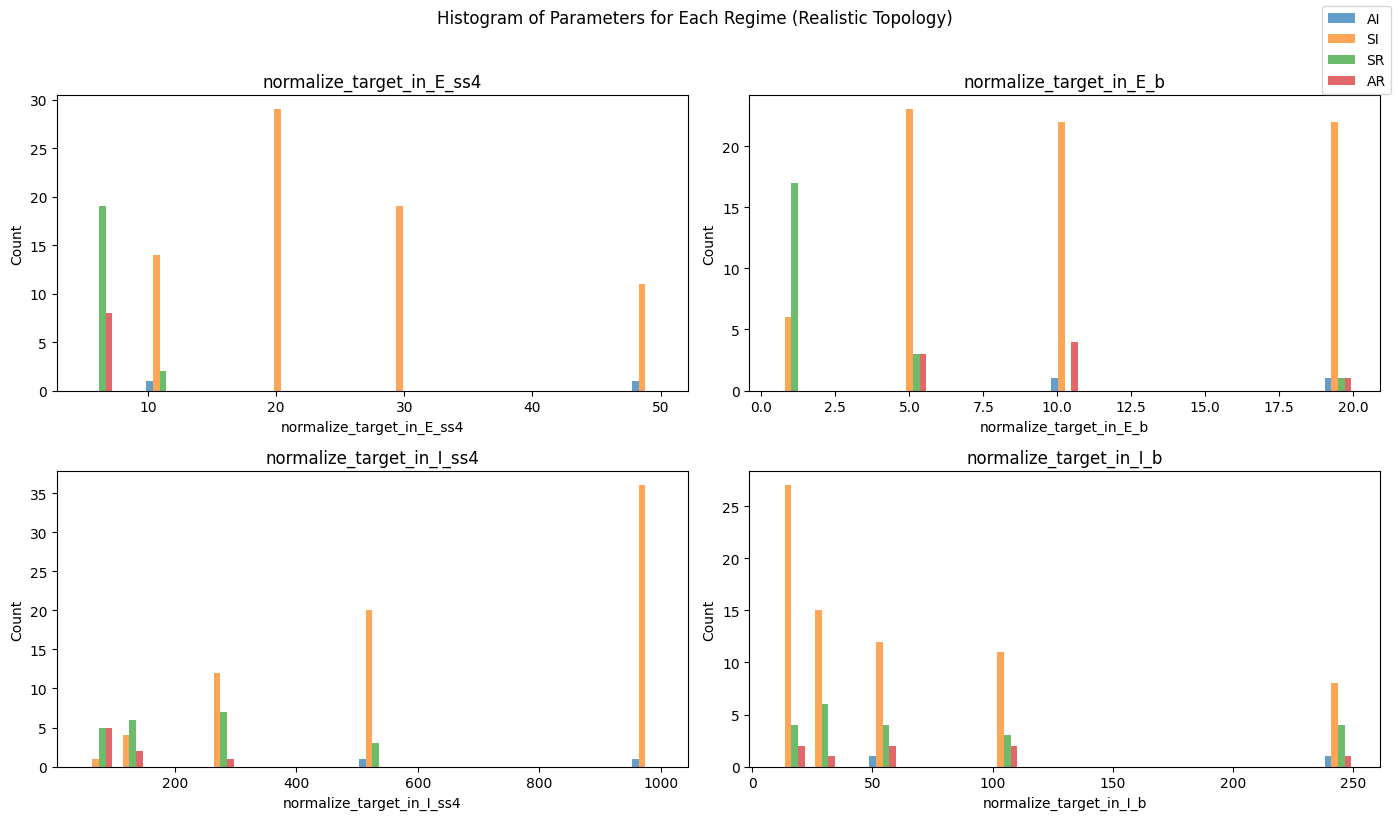

In [ ]:
# Find bins for each parameter based on the combined range across all filtered dataframes
bins_dict = {}
for col in parameter_columns:
    combined_min = min(
        filtered_df_AI[col].min(),
        filtered_df_SI[col].min(),
        filtered_df_SR[col].min(),
        filtered_df_AR[col].min(),
    )
    combined_max = max(
        filtered_df_AI[col].max(),
        filtered_df_SI[col].max(),
        filtered_df_SR[col].max(),
        filtered_df_AR[col].max(),
    )
    bins_dict[col] = np.linspace(combined_min, combined_max, 20)

# One figure with subplots (one per parameter)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for i, col in enumerate(parameter_columns):
    ax = axes[i]
    bins = bins_dict[col]
    centers = 0.5 * (bins[:-1] + bins[1:])
    bin_width = bins[1] - bins[0]
    bar_width = bin_width * 0.22

    counts_ai, _ = np.histogram(filtered_df_AI[col], bins=bins)
    counts_si, _ = np.histogram(filtered_df_SI[col], bins=bins)
    counts_sr, _ = np.histogram(filtered_df_SR[col], bins=bins)
    counts_ar, _ = np.histogram(filtered_df_AR[col], bins=bins)

    ax.bar(centers - 1.5 * bar_width, counts_ai, width=bar_width, alpha=0.7, label="AI")
    ax.bar(centers - 0.5 * bar_width, counts_si, width=bar_width, alpha=0.7, label="SI")
    ax.bar(centers + 0.5 * bar_width, counts_sr, width=bar_width, alpha=0.7, label="SR")
    ax.bar(centers + 1.5 * bar_width, counts_ar, width=bar_width, alpha=0.7, label="AR")

    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.set_title(col)

# Shared legend and title
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Histogram of Parameters for Each Regime (Realistic Topology)", y=1.02)
fig.tight_layout()
plt.show()